# 解答例（教員用）　第14回
***
> このノートブックは **模範解答の一例**です．コードの空欄（`TODO()`）を埋め，探索は複数ラウンドに分けて実行し，解答欄には実際に得られた出力の数値を根拠に書いています．
> 乱数を使う箇所は固定していますが，ライブラリのバージョンや実行環境によって数値が **小数第2〜3位ほどずれる**ことがあります．探索型の問題なので，**別の探索経路・別の最良設定でも，根拠が筋の通っていれば正解**です．

# 第14回　PyTorch 入門
***
> **前提**: 第13回まで Scikit-learn で機械学習の基礎（Pipeline，正則化，学習曲線など）を学びました。第13回では決定木の `max_depth` による過学習も確認しました。ニューラルネットワークでも epoch 数や層の深さで同様のことが起きます。第15回以降で損失曲線を描いて確認します。
>
> ここから **PyTorch** を使い，深層学習フレームワークの基礎（Tensor，DataLoader，MNIST）を学びます。第15回以降 q14→q15→q16→q17 と PyTorch で一本につながります。

> ⚠️ **この課題で身につけること：コーディングではなく「AI（ディープラーニング）の中身の理解」です。**
>
> コードは AI に書かせても構いません。重要なのは「**なぜその処理を選ぶのか**」「**パラメータや特徴量を変えると結果がどう変わるのか**」を理解し、提出物で示すことです。各問には学習目標を示すタグが付いています。
>
> | タグ | 意味 | あなたがすること |
> |---|---|---|
> | **【骨格】** | 動くコードは与えられている | 設計上の決定点（数値・選択肢・特徴量）だけを変更する |
> | **【選択】** | 適切な手法を選ぶ問題 | 複数候補から選び、**理由**を解答用コードセルに書く |
> | **【実験】** | 試行錯誤の記録 | パラメータ等を変えて結果を表に記録し、**考察**する |
> | **【説明】** | 理解の証跡 | 与えられたコードの各行に `# 説明:` で意味を書く |
> | **【探索】** | 最適設定を自分で探す | **仮説 → 試行 → 記録 → 次の仮説** を何度も繰り返す。全試行が自動で履歴に残る |
>
> コードは原則として完成形ですが、**各問の「核心となる最低限の数行」は `# ★あなたが書く★` として空欄**にしてあります（空欄は `TODO()` と書いてあり、そのまま実行すると「空欄が残っています」というエラーで止まります。`TODO()` を自分のコードに書き換えてください）。AI に頼り切らず、要となる処理は自分で書けることも確認します（ボイラープレートは提供済み）。
>
> 各問の **✍️ 解答用コードセル**（`# (1-a)` 形式の変数・文字列）に、設計判断・理由・実験結果・考察を**項目ごとに**記入してください。これが採点対象です。

---

## 🧪 この回の進め方：最適な設定は「自分で」探す

この回では **「正解のパラメータ」は教えません**。答えは、あなたが何度も試して見つけます。

```
  ①仮説を立てる → ②試す（1回1行の記録が自動で残る） → ③結果を見て仮説を直す → ①へ戻る
```

### 試行錯誤の記録帳 `Lab`（最初のコードセルで用意済み。中身を読んで使い方を理解すること）

| 使い方 | 何をするか |
|---|---|
| `lab.df()` | これまでの全試行を表で見る（試行番号・設定・スコア・仮説） |
| `lab.plot(x="lr", group=...)` | 設定とスコアの関係、ベスト更新の推移をグラフにする |
| `lab.report()` | 探索の自己診断（回数・範囲・端に張り付いていないか・仮説を書いたか） |
| `lab.final_test(...)` | **テストデータでの最終評価。1回しか実行できない** |
| `lab.save()` | 全履歴を CSV に保存する |

### ルール（ここが「AIの理解」の中心）

1. **探索に使ってよいのは検証スコア（訓練データの一部を取り分けた検証用データでの正解率）だけ**。テストデータは最後に **1回だけ**（見てから設定を変えたらデータリーク）。
2. **試行のたびに「仮説」を書く**（何を確かめたい試行か）。やみくもな総当たりは評価されません。
3. **粗く → 細かく**：まず桁・範囲を広く振って良さそうな所を掴み、次にその周辺を細かく調べる。
4. **ベストが探索範囲の端に来たら、範囲を広げて確かめる**。
5. 上位の設定同士の差が、ばらつきより小さいなら「差がある」とは言えない。
6. **実験の前に予測を書く**。予測と結果のズレが、あなたが得た「知識」の証拠になる。
7. 最後に、得た知識を **LLM への指示書**にまとめる（最終問題）。

### 評価の観点

| 観点 | 見られること |
|---|---|
| 試行の量と質 | 目安回数以上・仮説が毎回ある・粗→細の流れがある |
| 結果の読み取り | 外れた仮説から何を学んだか（試行番号 `#n` を引用して書く） |
| 検証の作法 | テストは1回だけ／検証スコアとテストの差を正しく解釈している |
| 知識の言語化 | 自分の実験結果を、LLM が実行できる指示書に落とせている |

## 目次
1. Tensor と自動微分
2. MNIST の読み込み
3. MNIST の可視化
4. DataLoader の理解

---

## この回で学ぶこと

### なぜ PyTorch を使うのか

これまで使ってきた scikit-learn は「既成のモデルを使う」ためのライブラリだ。PyTorch は「自分でニューラルネットワークを設計・実装する」ためのフレームワークで，現在の深層学習研究の標準となっている。

| | scikit-learn | PyTorch |
|---|---|---|
| 対象 | 機械学習（線形回帰〜XGBoost） | 深層学習（NN, CNN, Transformer） |
| 柔軟性 | 低（既成モデルを使う） | 高（自由にモデルを設計） |
| 研究での利用 | 特徴量エンジニアリング，ベースライン | 最先端モデルの実装 |

卒業研究で「画像認識」「自然言語処理」「時系列予測」などを扱うなら，PyTorch は必須のスキルだ。

### Tensor とは

Tensor は PyTorch の基本データ構造で，NumPy の `ndarray` に似ているが，以下の点が異なる：
- **GPU で計算できる**（`.to("cuda")`）：大規模モデルの学習を劇的に高速化
- **自動微分（Autograd）** をサポート：ニューラルネットワークの学習に必要な勾配を自動計算

### 自動微分（Autograd）の重要性

ニューラルネットワークの学習には，損失を各パラメータで微分する「誤差逆伝播法（Backpropagation）」が必要だ。これを手計算すると非常に複雑になるが，PyTorch の `requires_grad=True` を使えば自動的に計算できる。

### ミニバッチ学習と DataLoader

全データを一度に学習する「バッチ学習」は：
- メモリに収まらない大規模データでは不可能
- 勾配の計算が遅い

`DataLoader` は大きなデータを小さな「ミニバッチ」に分割して，少しずつ学習できるようにする。`shuffle=True` にすることで，毎エポック異なる順序でデータが供給され，モデルが特定の順序に依存しない学習ができる。

### GPU と CPU の使い分け

```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
```

- **GPU**: 深層学習の行列演算を並列処理で高速化（Colab の無料 GPU が使える）
- **CPU**: GPU がない環境でも動作する（今回のような小規模問題では十分）

データとモデルを同じデバイス（GPU か CPU）に置く必要がある。`.to(device)` でデバイスを指定する。

---

## 📚 将来の自分のためのメモ — 大学研究での応用


### どんな研究で使われるか

| 分野 | 具体例 |
|---|---|
| 情報科学・CS | 深層学習研究全般（学会の標準実装フレームワーク） |
| 医学画像 | CT/MRI の異常検知，病理画像分類 |
| 言語学・NLP | 文書分類，翻訳，大規模言語モデルのファインチューニング |
| ロボティクス | 視覚，制御ポリシーの学習 |
| 物理学・化学 | シミュレーション結果のニューラルネット近似（PINN など） |

### 応用できる場面

- **自分でモデル構造を設計・変更**したい（論文の新規手法の実装）
- **GPU で大規模学習**が必要
- **自動微分**で複雑な損失関数を試したい
- scikit-learn の既成モデルでは表現できない問題（画像，系列，グラフ）

### 応用しにくい・向かない場面

- **小規模な表形式データ**（数百〜数千行）— sklearn の線形モデルや XGBoost で十分なことが多い
- **統計的推論・因果推論**が主目的（p値，信頼区間— PyTorch は予測・学習向き）
- **解釈可能性**だけが求められる分析（係数の読み取りなど）
- 計算資源がなく，大規模モデルを学習できない環境
- 「Tensor と DataLoader を理解する」だけでは研究は完結しない— **第15回以降の学習ループ**が必須

### 研究で報告するときのポイント

1. **フレームワークとバージョン**（PyTorch x.x，CUDA など）を記載
2. `random_seed` の固定で**再現性**を確保
3. データの**前処理**（正規化，リサイズ）を学習・推論で一致させる（第17回へ続く）
4. Colab / クラスタなど**計算環境**を Methods に書く

### 関連する発展トピック（調べてみると良い）

- Hugging Face Transformers（NLP の標準）
- PyTorch Lightning（学習ループの整理）
- JAX / TensorFlow（他フレームワークとの比較）

In [ ]:
%pip install -q torch torchvision


In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset
import pandas as pd

DATA_ROOT = "./data"  # MNIST は torchvision が自動ダウンロード


# ==== 試行錯誤の記録帳（この回の全実験がここに溜まる。中身を読んで使い方を理解しておくこと）====
class Lab:
    """試行錯誤の記録帳。何回でも log() でき、表・グラフ・診断レポートにできる。
    ・スコア（score）は「検証用スコア（CV など）」だけを記録する。テストデータは final_test() で1回だけ。
    ・bounds = {パラメータ名: (下限, 上限)} … それ以上広げられない値（例：k の下限 2）。ベストがここにあっても「端」と警告しない。
    ・ignore = {パラメータ名: [値, ...]} … 範囲の計算から外す特別な値（例：正則化なしを表す alpha=0）。"""

    def __init__(self, name, score_name="cv_score", higher_is_better=True, bounds=None, ignore=None):
        self.name, self.score_name, self.hib = name, score_name, higher_is_better
        self.bounds, self.ignore = bounds or {}, ignore or {}
        self.rows, self.test_result = [], None

    def seen(self, params):
        return any(r["params"] == params for r in self.rows)

    def log(self, hypothesis, params, score, **extra):
        """1試行を記録する。同じ params を再度記録しようとすると無視する（重複の水増し防止）。"""
        if self.seen(params):
            print(f"  (skip) 既に試した設定です: {params}")
            return
        self.rows.append(dict(trial=len(self.rows) + 1, hypothesis=hypothesis.strip(),
                              params=dict(params), score=float(score), extra=extra))
        best = self.best()["trial"] == len(self.rows)
        print(f"  #{len(self.rows):02d} {params}  {self.score_name}={score:.4f}"
              + "".join(f"  {k}={v}" for k, v in extra.items()) + ("  ★ベスト更新" if best else ""))

    def df(self):
        import pandas as pd
        return pd.DataFrame([{"trial": r["trial"], **r["params"], self.score_name: round(r["score"], 4),
                              **r["extra"], "hypothesis": r["hypothesis"]} for r in self.rows])

    def best(self):
        return (max if self.hib else min)(self.rows, key=lambda r: r["score"])

    def plot(self, x, group=None, logx=True, query=None):
        """パラメータ x とスコアの関係（group ごとに線を分ける）と、試行回数ごとのベスト更新の推移。"""
        if not self.rows:
            print("まだ試行がありません（上の探索セルの TODO() を埋めて実行してください）"); return
        import matplotlib.pyplot as plt
        d = self.df()
        dd = d.query(query) if query else d
        fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
        for g, sub in (dd.groupby(group) if group else [("all", dd)]):
            sub = sub.sort_values(x)
            ax[0].plot(sub[x], sub[self.score_name], "o-", label=str(g))
        if logx and dd[x].dtype.kind in "if" and (dd[x] > 0).all(): ax[0].set_xscale("log")
        ax[0].set_xlabel(x); ax[0].set_ylabel(self.score_name); ax[0].legend(); ax[0].set_title("Parameter vs. validation score")
        cur = d[self.score_name].cummax() if self.hib else d[self.score_name].cummin()
        ax[1].step(d["trial"], cur, where="post"); ax[1].plot(d["trial"], d[self.score_name], "x", alpha=.5)
        ax[1].set_xlabel("Trial number"); ax[1].set_title("Best score so far (flat = plateau)")
        plt.tight_layout(); plt.show()

    def report(self, min_trials=15):
        """探索の質の自己診断：回数・カバー範囲・端に張り付いていないか・仮説を書いたか。"""
        if not self.rows:
            print("まだ試行がありません（上の探索セルの TODO() を埋めて実行してください）"); return
        d, n = self.df(), len(self.rows)
        print(f"■ 試行回数: {n}（目安 {min_trials} 回以上） → {'OK' if n >= min_trials else 'まだ足りない'}")
        keys = list(self.rows[0]["params"]) if n else []
        b = self.best()
        print(f"■ ベスト: trial#{b['trial']} {b['params']}  {self.score_name}={b['score']:.4f}")
        for k in keys:
            vals = [r["params"][k] for r in self.rows if r["params"][k] not in self.ignore.get(k, [])]
            uniq = sorted(set(map(str, vals)))
            line = f"■ {k}: {len(uniq)} 種類を試した"
            nums = [v for v in vals if isinstance(v, (int, float)) and not isinstance(v, bool)]
            if k != "seed" and vals and len(nums) == len(vals) and len(set(nums)) > 2:
                lo, hi = min(nums), max(nums)
                blo, bhi = self.bounds.get(k, (None, None))
                bv = b["params"][k]
                edge = (bv == lo and lo != blo) or (bv == hi and hi != bhi)
                line += f"（範囲 {lo:g}〜{hi:g}）" + (" ⚠ ベストが探索範囲の端 → 範囲を広げて確かめよう" if edge else "")
            print(line)
        w = sum(1 for r in self.rows if len(r["hypothesis"]) >= 8)
        print(f"■ 仮説を書いた試行: {w}/{n}" + ("" if w == n else " ⚠ 何を確かめる試行か毎回書こう"))
        if n >= 6:
            third = n // 3
            print(f"■ 前半の最高 {d[self.score_name][:third].max():.4f} → 後半の最高 {d[self.score_name][-third:].max():.4f}")

    def final_test(self, score_fn, name="最終テストスコア", compare=True):
        """テストデータでの最終評価。1回しか実行できない（2回目以降はエラー）。
        compare=False は、検証スコアと別の指標で評価するとき（並べて比べられないので表示しない）。"""
        if self.test_result is not None:
            raise RuntimeError(f"テストは既に使用済みです（結果 {self.test_result:.4f}）。テストを見て設定を変えるのはデータリークです。")
        self.test_result = float(score_fn())
        print(f"{name} = {self.test_result:.4f}"
              + (f"   （検証ベスト {self.score_name} = {self.best()['score']:.4f}）" if compare else ""))
        return self.test_result

    def save(self, path=None):
        path = path or f"{self.name}_log.csv"
        self.df().to_csv(path, index=False, encoding="utf-8-sig"); print("保存:", path)


def TODO():
    """「★あなたが書く★」の空欄。自分のコードに置き換えるまで、実行するとここで止まる。"""
    raise NotImplementedError("★あなたが書く★ の空欄（TODO()）がまだ残っています。自分のコードに書き換えてから再実行してください。")


## 問題1　Tensor と自動微分　【説明】
***

### Tensor の基本操作

NumPy の配列に似ているが，型には注意が必要だ：
- `torch.tensor([1, 2, 3])` → デフォルトは int64
- `torch.tensor([1.0, 2.0, 3.0])` → float32（NN で使う型）
- `x.dtype` で型を確認できる

### 自動微分の仕組み

`requires_grad=True` を設定すると，その Tensor を使った計算履歴（計算グラフ）が記録される：

```
x = 5.0 (requires_grad=True)
y = 2x² + 3

y.backward() を呼ぶと：
  dy/dx = 4x を計算 → x=5 なので dy/dx = 20.0
```

これがニューラルネットワークの学習の本質だ：
```
損失L を各重みw で偏微分 → dL/dw を計算（これが勾配）
→ w = w - lr × dL/dw（勾配降下法で重みを更新）
```

PyTorch はこの「勾配の計算」を自動化している。

### 課題

下のコードセルは，Tensor の **生成・形状・変形（reshape / view）・演算** と **自動微分** を確認する **完成形**です。今回は自分でコードを書くのではなく，**Tensor の挙動と自動微分の仕組みを読み解く**のが目的です。

**各行の `# 説明:` の右に，その行が何をしているかを自分の言葉で書いて**ください（コード自体は変更しないこと）。書き終えたらセルを実行し，出力を確認してください。

説明を書くときは，次の問いを意識してください：

- `shape` と `dtype` はそれぞれ何を表すか？ なぜ NN では `float32` を使うのか？
- `reshape` と `view` は何をするか？ 要素数が変わらないのはなぜか？
- `requires_grad=True` を付けると何が記録されるのか？ `backward()` は何を計算するのか？

> **確認**: `y = 2x² + 3` を微分すると `dy/dx = 4x`，x=5 を代入すると 4×5 = 20.0 になるはずです。出力が 20.0 になることを確認してください。

In [2]:
# 各行の「# 説明:」に自分の言葉で意味を書いてください（コードは変更しない）
# （説明は AI に書かせず、自分で書くこと）

# --- Tensor の生成・形状 ---
t = torch.tensor([1.0, 2.0, 3.0])           # 説明: Python のリストから 1 次元の Tensor（要素 3 個の float32 配列）を作る．
print("shape:", t.shape, " dtype:", t.dtype)  # 説明: shape は各次元の大きさ（ここでは torch.Size([3])），dtype は要素のデータ型（torch.float32）を表す．

# --- 形状の変形（reshape / view）---
a = torch.arange(6)                          # 説明: 0,1,2,3,4,5 の整数が入った 1 次元 Tensor（要素 6 個，dtype は int64）ができる．
b = a.reshape(2, 3)                          # 説明: 要素の並びはそのままで形だけ (2, 3)（2 行 3 列）に変える．要素数 6 = 2×3 は変わらない．
c = b.view(3, 2)                             # 説明: メモリ上のデータを共有したまま形を (3, 2) に見なす．reshape との違いは，view はメモリが連続でないとエラーになる点（reshape は必要ならコピーする）．
print("a:", a.shape, " b:", b.shape, " c:", c.shape)

# --- 要素ごとの演算 ---
s = b + 10                                   # 説明: 全要素に 10 を足す．Tensor の演算は要素ごとに行われる（ブロードキャストでスカラー 10 が全要素に適用される）．
print("b + 10 =\n", s)

# --- 自動微分（Autograd）---
x = torch.tensor(5.0, requires_grad=True)    # 説明: x=5.0 の Tensor を作り，この値に対する勾配を記録する（自動微分の対象にする）ことを指定する．
y = 2.0 * x ** 2 + 3.0                        # 説明: y = 2x² + 3 を計算する．requires_grad=True の x から計算されるので，計算の履歴（計算グラフ）が記録される．
y.backward()                                 # 説明: 逆伝播．計算グラフをたどって dy/dx（y を x で微分した値）を自動で計算し，x.grad に格納する．
print("dy/dx =", x.grad.item())              # 説明: x.grad（dy/dx = 4x = 20.0）を Python の数値として取り出して表示する．理論値と一致する．


shape: torch.Size([3])  dtype: torch.float32
a: torch.Size([6])  b: torch.Size([2, 3])  c: torch.Size([3, 2])
b + 10 =
 tensor([[10, 11, 12],
        [13, 14, 15]])


dy/dx = 20.0


In [3]:
# === ✍️ 問題1 解答（採点対象）===
# 主な提出物は上のコードセルへの # 説明: 記入。以下も記入すること。

# (1-a) `shape` と `dtype` はそれぞれ何を表すか／なぜ NN では `float32` を使うか
answer_1_a = """
shape は Tensor の各次元の大きさ（例：torch.Size([3])、画像なら (1, 28, 28)）、dtype は要素のデータ型（float32 など）。NN で float32 を使うのは、64 ビット（float64）より半分のメモリで高速に計算でき、学習に必要な精度は十分で、GPU も float32 に最適化されているから。
"""

# (1-b) `reshape` と `view` は何をするか／要素数が変わらないのはなぜか
answer_1_b = """
reshape は要素の並びを変えずに形だけを変える（必要ならコピー）。view はメモリを共有したまま形を見なし直す（メモリが連続でないとエラー）。どちらも並べ替え方を変えるだけで要素そのものは増減しないので、変形前後で要素数は変わらない（6 = 2×3 = 3×2）。
"""

# (1-c) `requires_grad=True` を付けると何が記録され、`backward()` は何を計算するか
answer_1_c = """
requires_grad=True を付けると、その Tensor を含む計算の履歴（計算グラフ）が記録される。backward() は、記録された計算グラフを終点（y）から逆にたどり、連鎖律で各パラメータに対する勾配（dy/dx）を計算して x.grad に入れる。
"""

# (1-d) 確認：`dy/dx` の出力値は？ 理論値 20.0 と一致したか
answer_1_d = """
dy/dx = 20.0 と出力され、理論値（4x = 4×5 = 20.0）と一致した。
"""



## 問題2　MNIST データセットの読み込み　【選択+説明】
***

### MNIST とは

MNIST（Modified National Institute of Standards and Technology）は，手書き数字（0〜9）の画像データセットだ：
- 訓練データ：60,000枚
- テストデータ：10,000枚
- 画像サイズ：28×28 ピクセル（グレースケール）
- クラス数：10（数字0〜9）

機械学習の "Hello World" として広く使われており，新しいモデルの動作確認に最適だ。

### `transforms.ToTensor()` が行うこと

`PIL.Image` 形式の画像（ピクセル値 0〜255, uint8）を PyTorch Tensor（値 0.0〜1.0, float32）に変換する：

```
原画像: shape (28, 28), dtype uint8, 値 0〜255
変換後: shape (1, 28, 28), dtype float32, 値 0.0〜1.0

【変換の意味】
・チャネル次元が追加（グレースケールなので 1 チャネル）
・値を 255 で割って正規化（NN の学習を安定化させる）
```

### `batch_size=64` の選び方

バッチサイズはハイパーパラメータの一つ：
- 大きいバッチ（256, 512）：GPU を効率よく使える，勾配が安定，メモリ消費大
- 小さいバッチ（32, 64）：メモリ消費小，ノイズが多く局所最適解から抜けやすいことも
- **64や128が多くの場面でバランスが良い**

### 課題

下のコードセルは，MNIST を読み込んで `DataLoader` を作る **完成形**です。ここでは2つのことをします。

**(1) 選択：`transform` を選ぶ**

`# === ★選択：使う transform を選ぶ★ ===` の `transform_choice` を `"A"`〜`"F"` から選んでください。選んだ値が実際の前処理に反映されます。

- **(A) `ToTensor` のみ** … ピクセル値を 0〜255 から 0.0〜1.0 に変換するだけ
- **(B) `ToTensor` + `Normalize(0.5, 0.5)`** … おおまかに -1〜1 に標準化
- **(C) `ToTensor` + `Normalize`（MNIST の統計 0.1307/0.3081）** … 平均約0・分散約1に標準化
- **(D) `ToTensor` + `RandomRotation(15)`** … ランダムに±15度回転（データ拡張）
- **(E) `ToTensor` + `RandomHorizontalFlip()`** … ランダムに左右反転
- **(F) `ToTensor` + `RandomErasing()`** … 画像の一部をランダムに消す（データ拡張）

> **設計判断**: MNIST の数字認識を学習する目的に対して、最も適切な transform を選び、理由を解答用コードセルに書いてください。**不適切な選択肢も混ざっています**（例えば (E) 左右反転は「6 と 9」「2」などの形を壊すため数字認識には不向きです）。正規化が学習を安定させる理由、データ拡張が有効な場合とそうでない場合にも触れてください。

**(2) 説明＋最低限コーディング：Dataset / DataLoader の構築**

各行の `# 説明:` の右に意味を書いてください（特に `batch_size` と `shuffle` が何をするか）。なお、**DataLoader を作る1行はあなたが書きます**（`# ★あなたが書く★`）。書き終えたら実行し、サンプル数と1件目の情報を確認してください。

### MNIST の生データを見てみよう（実行するだけ）

`transform` を適用する前の MNIST の 1 枚目です．**画像がどんな型・大きさ・値で入っているか**を確認してください（このあと `transform` で Tensor に変換します）．

In [4]:
# === データの中身を確認する（実行するだけ。コードは変更しない）===
_raw = datasets.MNIST(root=DATA_ROOT, train=True, download=True)      # transform なし
_img, _label = _raw[0]
_arr = np.array(_img)
print("1 件目の型:", type(_img).__name__, " ラベル:", _label)
print("画像の大きさ:", _arr.shape, "（高さ, 幅）  値の範囲:", _arr.min(), "〜", _arr.max(), "（整数）")
print("枚数:", len(_raw))
print("画像の一部（真ん中付近 8x8）:")
print(_arr[10:18, 10:18])

Failed to download (trying next):
HTTP Error 404: Not Found



0.3%

0.7%

1.0%

1.3%

...

100.0%

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

1 件目の型: Image  ラベル: 5
画像の大きさ: (28, 28) （高さ, 幅）  値の範囲: 0 〜 255 （整数）
枚数: 60000
画像の一部（真ん中付近 8x8）:
[[  1 154 253  90   0   0   0   0]
 [  0 139 253 190   2   0   0   0]
 [  0  11 190 253  70   0   0   0]
 [  0   0  35 241 225 160 108   1]
 [  0   0   0  81 240 253 253 119]
 [  0   0   0   0  45 186 253 253]
 [  0   0   0   0   0  16  93 252]
 [  0   0   0   0   0   0   0 249]]


In [5]:
# === ★選択：使う transform を選ぶ（"A"〜"F"）★ ===
transform_choice = "C"

_transforms = {
    "A": transforms.ToTensor(),
    "B": transforms.Compose([transforms.ToTensor(),
                             transforms.Normalize((0.5,), (0.5,))]),
    "C": transforms.Compose([transforms.ToTensor(),
                             transforms.Normalize((0.1307,), (0.3081,))]),
    "D": transforms.Compose([transforms.ToTensor(),
                             transforms.RandomRotation(15)]),
    "E": transforms.Compose([transforms.ToTensor(),
                             transforms.RandomHorizontalFlip()]),
    "F": transforms.Compose([transforms.ToTensor(),
                             transforms.RandomErasing()]),
}
transform = _transforms[transform_choice]

# --- 以下の「# 説明:」に意味を書いてください（batch_size, shuffle に注目）---
train_dataset = datasets.MNIST(
    root=DATA_ROOT, train=True, download=True, transform=transform
)                                                            # 説明: MNIST の訓練用データ（60000 枚）を読み込む（train=False ならテスト用 10000 枚）．なければダウンロードし，transform で前処理を適用する．

# ★あなたが書く★：train_dataset から batch_size=64・shuffle=True の DataLoader を作る（1行）
#   ヒント: DataLoader(データセット, batch_size=..., shuffle=...)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)                                           # 説明: データセットをバッチサイズ 64 のミニバッチに分けて取り出す DataLoader．shuffle=True で各エポックごとにデータの順番をランダムにし，偏りを防ぐ．

print("サンプル数:", len(train_dataset))                     # 説明: 訓練データの枚数（60000）を表示する．
img, label = train_dataset[0]                                # 説明: 1 件目を取り出す．(画像 Tensor, ラベル) のタプルが返る．画像は (1, 28, 28) の Tensor，ラベルは整数（0〜9）．
print("1件目の画像 shape:", img.shape, " ラベル:", label)    # 説明: 1 件目の画像の形 (1, 28, 28)（チャンネル数 1・高さ 28・幅 28）とラベルを表示する．


サンプル数: 60000
1件目の画像 shape: torch.Size([1, 28, 28])  ラベル: 5


In [6]:
# === ✍️ 問題2 解答（採点対象）===
# 主な提出物は上のコードセルへの # 説明: 記入。以下も記入すること。

# (2-a) 設計判断：選んだ transform（A〜F）：(　)
# (A) ToTensor のみ
# (B) ToTensor + Normalize(0.5, 0.5)
# (C) ToTensor + Normalize（MNIST の統計 0.1307/0.3081）
# (D) ToTensor + RandomRotation(15)
# (E) ToTensor + RandomHorizontalFlip()
# (F) ToTensor + RandomErasing()
design2_choice = "C"
# (2-b) その理由（なぜ正規化が学習を安定させるか／データ拡張が有効・不向きな場合）
answer_2_b = """
(C) ToTensor + Normalize(0.1307, 0.3081) を選ぶ。MNIST は 0〜1 の画素値の大半が 0（黒背景）で平均が約 0.13 と偏っている。標準化で平均 0・分散 1 にすると、入力のスケールが揃い、勾配の大きさが安定して学習率を大きく取れ、収束が速くなる。データ拡張（回転・消去）は、テスト時の変化（傾き・欠損）に強くするために有効だが、学習エポックが少ないと学習が難しくなり逆効果になりうる。
"""

# (2-c) 不適切だと思う選択肢を1つ挙げ、なぜ MNIST に不向きか
answer_2_c = """
(E) RandomHorizontalFlip（左右反転）。数字は左右反転すると別の形になる（例：2 が鏡文字になる、6 と 9 の区別が崩れる）ので、正しい教師（ラベル）と画像が対応しなくなり、学習を妨げる。問題2' の #5 でも最下位（0.7975）だった。
"""


## 問題2'　前処理・学習設定の最適な組合せを自分で探す　【探索】
***

### 課題

問題2で選んだ transform（A〜F）は「理屈」で選びました。ここでは**軽い学習を何度も回して、実際に検証スコアが高い設定を探します**。理屈と実験結果がずれたら、その理由を考えるのが目的です。

| 軸 | 選択肢 | 注意点 |
|---|---|---|
| `key` | 問題2の transform `"A"`〜`"F"` | 不適切な選択肢も混ざっている。実際に悪いのか確かめる |
| `lr` | 学習率（SGD）。0.001〜1 など桁で振る | 大きすぎ・小さすぎの両方に罠がある |
| `epochs` | 学習回数 1〜5 | 増やすと計算時間も増える |
| `batch_size` | 16〜256 | 問題4で見る「1エポックの更新回数」と関係する |
| `seed` | 乱数シード | **同じ設定でもシードで結果が変わる。僅差の比較には複数シードで確かめる** |

### 検証の作法

- 学習には MNIST の訓練データのうち **先頭 8000 枚**、検証には**別の 2000 枚**（訓練データの 50000〜52000 番。**データ拡張なし**）を使います。
- MNIST の**テストデータ（10000枚）は最終評価の 1回だけ**。

### 課題

1. **【実験前に先に書く】** 予測セルに、最良の `key`・`lr` の予測と理由を書く。
2. 探索セルの `hypothesis` と `settings` を書き換えて何度も実行（**15回以上**、`key`・`lr` を含む3軸以上を動かす）。**核心（正解数を数える1行）はあなたが書きます**。
3. 経過確認セルで確認して次の一手を決める。
4. 最終評価セルを **1回だけ**実行する（選んだ設定を訓練データ 8000 枚で学習し、テストデータ全体で評価）。
5. 解答セルに書く。

> **考察**: 一番良かった／悪かった transform とその理由。問題2で選んだ transform は実験結果と一致しましたか？ 差が「シードによるばらつき」の範囲かどうかを、同じ設定を別シードで試した結果で示してください。

In [7]:
# === ✍️ 問題2'-0 実験前の予測（実験を始める前に書く。実験後に書き直さない）===

# 検証スコアが最も高くなると思う transform（A〜F）と学習率 lr
prediction_2_key = "C"
prediction_2_lr = 0.1
# そう予測した理由（知識・直感・LLMの回答など。LLMに聞いた場合は回答を貼り、自分との違いも書く）
prediction_2_reason = """
正規化（C: MNIST の平均・標準偏差で標準化）は入力のスケールをそろえて勾配を安定させるので、最も学習が速く精度が高いと予想した。SGD の学習率は 0.01〜0.1 くらいが標準的なので lr=0.1 が最良と考えた（LLM に聞いても「SGD なら 0.01〜0.1」）。左右反転（E）は 6 と 9 を混同させるので悪化すると予想した。
"""

In [8]:
# === 完成済みコード（★の箇所だけ自分で書く）：試す → lab に記録、を繰り返せる形になっている ===
lab = Lab("q14_mnist", score_name="val_acc")
N_TRAIN, N_VAL = 8000, 2000       # 学習に使う枚数／検証に使う枚数（訓練データ内で重ならない範囲）

_norms = {"B": transforms.Normalize((0.5,), (0.5,)), "C": transforms.Normalize((0.1307,), (0.3081,))}

def eval_transform_for(key):
    """検証・テスト画像にはデータ拡張をかけない。Normalize だけ訓練と同じものを使う。"""
    return transforms.Compose([transforms.ToTensor(), _norms[key]]) if key in _norms else transforms.ToTensor()

def train_net(key, lr, epochs, batch_size, seed):
    """指定設定で N_TRAIN 枚を使って学習し、学習済みの net を返す（完成形）"""
    torch.manual_seed(seed)
    tr = Subset(datasets.MNIST(DATA_ROOT, train=True, download=True, transform=_transforms[key]), range(N_TRAIN))
    net = nn.Sequential(nn.Flatten(), nn.Linear(28 * 28, 128), nn.ReLU(), nn.Linear(128, 10))
    opt = optim.SGD(net.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for x, y in DataLoader(tr, batch_size=batch_size, shuffle=True):
            opt.zero_grad()
            loss_fn(net(x), y).backward()
            opt.step()
    return net

def accuracy(net, dataset):
    correct = 0
    with torch.no_grad():
        for x, y in DataLoader(dataset, batch_size=1000):
            # ★あなたが書く★：このバッチで正解した枚数を correct に足す（1行）
            #   ヒント: (net(x).argmax(dim=1) == y).sum().item()
            correct += (net(x).argmax(dim=1) == y).sum().item()
    return correct / len(dataset)

def run_trial(hypothesis, key, lr, epochs, batch_size, seed):
    """1つの設定を試して lab に記録する（同じ設定は2回記録されない）"""
    params = {"key": key, "lr": lr, "epochs": epochs, "batch_size": batch_size, "seed": seed}
    if lab.seen(params):
        print(f"  (skip) 既に試した設定です: {params}"); return
    net = train_net(key, lr, epochs, batch_size, seed)
    val_ds = Subset(datasets.MNIST(DATA_ROOT, train=True, download=True, transform=eval_transform_for(key)),
                    range(50000, 50000 + N_VAL))
    lab.log(hypothesis, params, accuracy(net, val_ds))

# === ★ここを変えて実験する★：仮説を書き、settings を書き換えて何度でも実行 ===
# 【変更のしかた】
#  ① hypothesis … 今回の試行で「何を確かめたいか」を1文で書き換える（例：「alpha を10倍にすると CV は上がるはず」）。空・短すぎると report で警告される
#  ② settings   … 試したい設定を「1行に1つのタプル」で並べる。タプルの並び順は (key, lr, epochs, batch_size, seed)
#       key … 前処理の種類 "A"〜"F"（問題2の選択肢と同じ）
#       lr … SGD の学習率（0.005〜0.5 など桁で振る）
#       epochs … 学習回数（1〜5）
#       batch_size … ミニバッチの大きさ（16〜256）
#       seed … 乱数シード。同じ設定を別シードで試すとばらつきが分かる
#     行を足す／消す／数値を書き換えてよい。例：settings = [(k, 0.05, 2, 64, 0) for k in "ABCDEF"]
#  ③ 実行すると、この settings の各行が1試行として lab に記録される（前に試した試行は消えず、同じ設定は重複記録されない）
#  ④ 下の「経過の確認」セルで結果を見て、①②を書き換えて再実行する（これを何回も繰り返す）
#  ※ 15 回以上。key と lr を含む 3 軸以上を動かすこと。
# 進め方の例： ①key(A〜F) を同じ条件で比べる → ②lr を桁で振る → ③良さそうな所を別シードで確かめる
hypothesis = "まず lr=0.05, epochs=2 に固定して transform A〜F を比べる"
settings = [(k, 0.05, 2, 64, 0) for k in "ABCDEF"]      # (key, lr, epochs, batch_size, seed)
for key, lr, epochs, bs, seed in settings:
    run_trial(hypothesis, key, lr, epochs, bs, seed)

  #01 {'key': 'A', 'lr': 0.05, 'epochs': 2, 'batch_size': 64, 'seed': 0}  val_acc=0.8540  ★ベスト更新


  #02 {'key': 'B', 'lr': 0.05, 'epochs': 2, 'batch_size': 64, 'seed': 0}  val_acc=0.8700  ★ベスト更新


  #03 {'key': 'C', 'lr': 0.05, 'epochs': 2, 'batch_size': 64, 'seed': 0}  val_acc=0.9005  ★ベスト更新


  #04 {'key': 'D', 'lr': 0.05, 'epochs': 2, 'batch_size': 64, 'seed': 0}  val_acc=0.8640


  #05 {'key': 'E', 'lr': 0.05, 'epochs': 2, 'batch_size': 64, 'seed': 0}  val_acc=0.7975


  #06 {'key': 'F', 'lr': 0.05, 'epochs': 2, 'batch_size': 64, 'seed': 0}  val_acc=0.8540


In [9]:
hypothesis = "最有力の C（正規化）で lr を桁で振る。lr が小さすぎて学習不足になっていないか"
settings = [("C", 0.01, 2, 64, 0), ("C", 0.1, 2, 64, 0), ("C", 0.5, 2, 64, 0), ("C", 1.0, 2, 64, 0)]
for key, lr, epochs, bs, seed in settings:
    run_trial(hypothesis, key, lr, epochs, bs, seed)

  #07 {'key': 'C', 'lr': 0.01, 'epochs': 2, 'batch_size': 64, 'seed': 0}  val_acc=0.8580


  #08 {'key': 'C', 'lr': 0.1, 'epochs': 2, 'batch_size': 64, 'seed': 0}  val_acc=0.9145  ★ベスト更新


  #09 {'key': 'C', 'lr': 0.5, 'epochs': 2, 'batch_size': 64, 'seed': 0}  val_acc=0.9305  ★ベスト更新


  #10 {'key': 'C', 'lr': 1.0, 'epochs': 2, 'batch_size': 64, 'seed': 0}  val_acc=0.5090


,trial,key,lr,epochs,batch_size,seed,val_acc
8,9,C,0.50,2,64,0,0.9305
7,8,C,0.10,2,64,0,0.9145
2,3,C,0.05,2,64,0,0.9005
1,2,B,0.05,2,64,0,0.8700
3,4,D,0.05,2,64,0,0.8640
6,7,C,0.01,2,64,0,0.8580
0,1,A,0.05,2,64,0,0.8540
5,6,F,0.05,2,64,0,0.8540


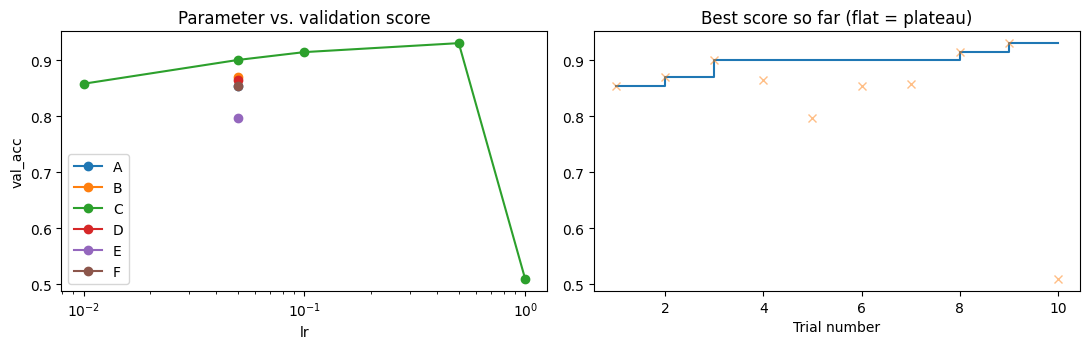

■ 試行回数: 10（目安 15 回以上） → まだ足りない
■ ベスト: trial#9 {'key': 'C', 'lr': 0.5, 'epochs': 2, 'batch_size': 64, 'seed': 0}  val_acc=0.9305
■ key: 6 種類を試した
■ lr: 5 種類を試した（範囲 0.01〜1）
■ epochs: 1 種類を試した
■ batch_size: 1 種類を試した
■ seed: 1 種類を試した
■ 仮説を書いた試行: 10/10
■ 前半の最高 0.9005 → 後半の最高 0.9305


In [10]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
display(lab.df().drop(columns="hypothesis").sort_values("val_acc", ascending=False).head(8))
lab.plot(x="lr", group="key")                 # lr と検証正解率、ベスト更新の推移
lab.report(min_trials=15)

In [11]:
hypothesis = "lr=0.5 で epochs=3 に。A（正規化なし）との差、別シードでの再現性を確認"
settings = [("C", 0.5, 3, 64, 0), ("C", 0.5, 3, 64, 1), ("C", 0.5, 3, 64, 2), ("A", 0.5, 3, 64, 0), ("A", 0.5, 3, 64, 1)]
for key, lr, epochs, bs, seed in settings:
    run_trial(hypothesis, key, lr, epochs, bs, seed)

  #11 {'key': 'C', 'lr': 0.5, 'epochs': 3, 'batch_size': 64, 'seed': 0}  val_acc=0.9405  ★ベスト更新


  #12 {'key': 'C', 'lr': 0.5, 'epochs': 3, 'batch_size': 64, 'seed': 1}  val_acc=0.9300


  #13 {'key': 'C', 'lr': 0.5, 'epochs': 3, 'batch_size': 64, 'seed': 2}  val_acc=0.9260


  #14 {'key': 'A', 'lr': 0.5, 'epochs': 3, 'batch_size': 64, 'seed': 0}  val_acc=0.9315


  #15 {'key': 'A', 'lr': 0.5, 'epochs': 3, 'batch_size': 64, 'seed': 1}  val_acc=0.9075


,trial,key,lr,epochs,batch_size,seed,val_acc
10,11,C,0.50,3,64,0,0.9405
13,14,A,0.50,3,64,0,0.9315
8,9,C,0.50,2,64,0,0.9305
11,12,C,0.50,3,64,1,0.9300
12,13,C,0.50,3,64,2,0.9260
7,8,C,0.10,2,64,0,0.9145
14,15,A,0.50,3,64,1,0.9075
2,3,C,0.05,2,64,0,0.9005


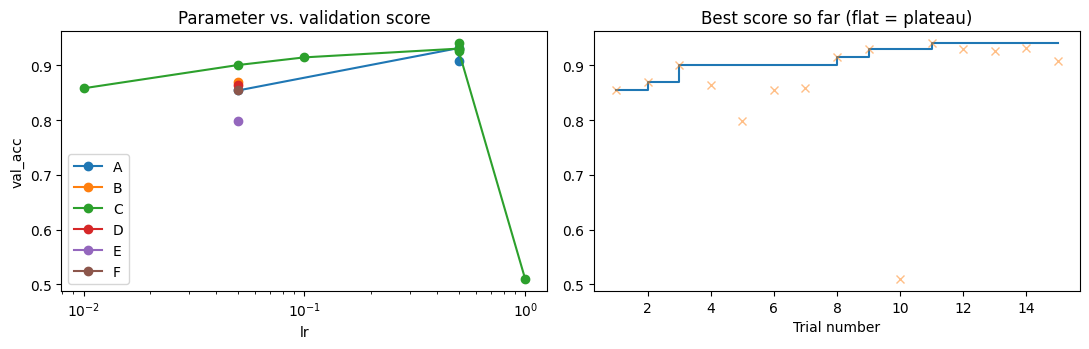

■ 試行回数: 15（目安 15 回以上） → OK
■ ベスト: trial#11 {'key': 'C', 'lr': 0.5, 'epochs': 3, 'batch_size': 64, 'seed': 0}  val_acc=0.9405
■ key: 6 種類を試した
■ lr: 5 種類を試した（範囲 0.01〜1）
■ epochs: 2 種類を試した
■ batch_size: 1 種類を試した
■ seed: 3 種類を試した
■ 仮説を書いた試行: 15/15
■ 前半の最高 0.9005 → 後半の最高 0.9405


In [12]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
display(lab.df().drop(columns="hypothesis").sort_values("val_acc", ascending=False).head(8))
lab.plot(x="lr", group="key")                 # lr と検証正解率、ベスト更新の推移
lab.report(min_trials=15)

In [13]:
hypothesis = "batch_size を変えると更新回数が変わる。lr=1.0 は大きすぎるか"
settings = [("C", 0.5, 3, 16, 0), ("C", 0.5, 3, 256, 0), ("C", 1.0, 3, 64, 0)]
for key, lr, epochs, bs, seed in settings:
    run_trial(hypothesis, key, lr, epochs, bs, seed)

  #16 {'key': 'C', 'lr': 0.5, 'epochs': 3, 'batch_size': 16, 'seed': 0}  val_acc=0.6100


  #17 {'key': 'C', 'lr': 0.5, 'epochs': 3, 'batch_size': 256, 'seed': 0}  val_acc=0.9225


  #18 {'key': 'C', 'lr': 1.0, 'epochs': 3, 'batch_size': 64, 'seed': 0}  val_acc=0.4030


,trial,key,lr,epochs,batch_size,seed,val_acc
10,11,C,0.5,3,64,0,0.9405
13,14,A,0.5,3,64,0,0.9315
8,9,C,0.5,2,64,0,0.9305
11,12,C,0.5,3,64,1,0.9300
12,13,C,0.5,3,64,2,0.9260
16,17,C,0.5,3,256,0,0.9225
7,8,C,0.1,2,64,0,0.9145
14,15,A,0.5,3,64,1,0.9075


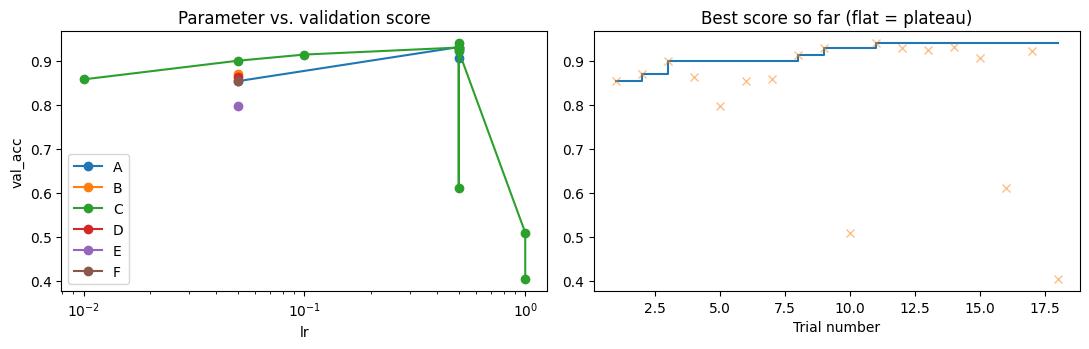

■ 試行回数: 18（目安 15 回以上） → OK
■ ベスト: trial#11 {'key': 'C', 'lr': 0.5, 'epochs': 3, 'batch_size': 64, 'seed': 0}  val_acc=0.9405
■ key: 6 種類を試した
■ lr: 5 種類を試した（範囲 0.01〜1）
■ epochs: 2 種類を試した
■ batch_size: 3 種類を試した（範囲 16〜256）
■ seed: 3 種類を試した
■ 仮説を書いた試行: 18/18
■ 前半の最高 0.9005 → 後半の最高 0.9315


In [14]:
# === 経過の確認（何度でも実行）：次の一手を決める材料 ===
display(lab.df().drop(columns="hypothesis").sort_values("val_acc", ascending=False).head(8))
lab.plot(x="lr", group="key")                 # lr と検証正解率、ベスト更新の推移
lab.report(min_trials=15)

In [15]:
# === 最終評価：探索を終えたら「1回だけ」実行する（2回目はエラー。テストを見て設定を変えるのはリーク）===
FINAL = dict(lab.best()["params"])   # 既定は検証最良。選び直すなら書き換える（理由は解答欄へ）
final_net = train_net(**FINAL)
test_ds = datasets.MNIST(DATA_ROOT, train=False, download=True, transform=eval_transform_for(FINAL["key"]))
lab.final_test(lambda: accuracy(final_net, test_ds))
print("採用した設定:", FINAL)

最終テストスコア = 0.9353   （検証ベスト val_acc = 0.9405）
採用した設定: {'key': 'C', 'lr': 0.5, 'epochs': 3, 'batch_size': 64, 'seed': 0}


In [16]:
# === ✍️ 問題2' 解答（採点対象）===
import pandas as pd

# (2'-a) 実験ログ（自動出力。15回以上・key と lr を含む3軸以上を動かすこと）
experiment_log = lab.df()
print(experiment_log.drop(columns="hypothesis").to_string())
lab.save()

# (2'-b) 探索の進め方：各段階で何を見て次の試行を決めたか（試行番号 #n を引用）
answer_2_e = """
【#1〜#6】lr=0.05・2 エポックに固定して transform A〜F を比較。C（0.9005）> B（0.87）> D（0.864）> A・F（0.854）> E（0.7975）。
【#7〜#10】最有力の C で lr を桁で振る：0.01 → 0.858、0.05 → 0.9005（#3）、0.1 → 0.9145、0.5 → 0.9305、1.0 → 0.509（発散）。最良 0.5 は探索範囲（0.01〜1.0）の端ではなく、1.0 で崩れるので上限が見えた。
【#11〜#15】lr=0.5 で epochs=3 にし、別シードで再現性を確認：C の seed 0/1/2 は 0.9405 / 0.9300 / 0.9260、A（正規化なし）の seed 0/1 は 0.9315 / 0.9075。
【#16〜#18】batch_size と lr=1.0 の確認：batch_size=16 は 0.61（更新回数が多すぎ、lr=0.5 が相対的に大きすぎて不安定）、256 は 0.9225、lr=1.0 は 0.403。
"""

# (2'-c) 仮説が外れた試行を1つ以上取り上げ、なぜ外れたか・何を学んだか（#n を引用）
answer_2_f = """
仮説「lr=0.1 が最良」は外れた（#8: 0.9145 < #9 lr=0.5: 0.9305）。SGD は Adam より学習率が大きくないと 2 エポックでは学習が足りない。もう 1 つ、仮説「batch_size を小さくすれば更新回数が増えて有利」も外れた（#16: batch_size=16, lr=0.5 は 0.61 と大崩れ）。バッチが小さいと勾配のばらつきが大きく、同じ lr では不安定になる。学習率とバッチサイズは独立ではなく、連動して決める必要がある。
"""

# (2'-d) 最良設定と val_acc。最終テストの結果は検証の値と比べてどうだったか（差の解釈）
answer_2_g = """
最良は #11（key=C, lr=0.5, epochs=3, batch_size=64, seed=0）で val_acc=0.9405。最終テスト精度は 0.9353 で、検証より 0.005 低い。差はシード違いのばらつき（0.914〜0.9405）よりずっと小さく、検証とテストがほぼ一致していると解釈できる。報告する性能はテストの 0.935。
"""

# (2'-e) 実験結果の考察：一番良かった／悪かった transform とその理由。(2-a) の選択は結果と一致したか。同じ設定を別シードで試した結果（#n）から、差がシードのばらつきの範囲か判断する
answer_2_h = """
一番良かったのは C（正規化）で、悪かったのは E（左右反転: 0.7975）。同じ条件（#1〜#6）では C 0.9005 > B 0.87 > D 0.864 > A/F 0.854 > E 0.7975。(2-a) で選んだ C と一致した。ただし C と A の差は lr=0.5・3 エポック（#11〜#15）では、C 0.9405 / 0.9300 / 0.9260（平均 0.932）、A 0.9315 / 0.9075（平均 0.919）と 0.013 の差で、C の seed 違い（0.9260〜0.9405、幅 0.0145）と同程度。したがって「正規化が有意に良い」とはこの探索だけでは言えない（傾向はある）。E の悪さは 0.05 以上の差で、シードのばらつきを超えており、確実な悪化。
"""

# (2'-f) 実験前の予測（prediction_2_*）と実際を比べる。どこがズレた？ 正しかった知識／間違っていた知識は？
answer_2_i = """
予測は key=C（当たり）、lr=0.1（外れ。最良は 0.5）。「E が最悪」も当たり。ズレの原因は SGD の学習率のスケール感で、ドキュメントの「SGD は Adam より大きめ」という知識が抜けていた。正しかった知識：正規化は有利、左右反転は有害。間違っていた知識：最適な lr の桁（0.1 でなく 0.5）。
"""

    trial key    lr  epochs  batch_size  seed  val_acc
0       1   A  0.05       2          64     0   0.8540
1       2   B  0.05       2          64     0   0.8700
2       3   C  0.05       2          64     0   0.9005
3       4   D  0.05       2          64     0   0.8640
4       5   E  0.05       2          64     0   0.7975
5       6   F  0.05       2          64     0   0.8540
6       7   C  0.01       2          64     0   0.8580
7       8   C  0.10       2          64     0   0.9145
8       9   C  0.50       2          64     0   0.9305
9      10   C  1.00       2          64     0   0.5090
10     11   C  0.50       3          64     0   0.9405
11     12   C  0.50       3          64     1   0.9300
12     13   C  0.50       3          64     2   0.9260
13     14   A  0.50       3          64     0   0.9315
14     15   A  0.50       3          64     1   0.9075
15     16   C  0.50       3          16     0   0.6100
16     17   C  0.50       3         256     0   0.9225
17     18 

## 問題3　MNIST の可視化　【骨格】
***

### なぜデータを可視化するのか

「データを見る」ことは機械学習の最も基本的なステップだ。以下を確認することが重要：
1. データが正しく読み込めているか（画像が正しく表示されるか）
2. ラベルと画像が対応しているか
3. データの品質（ぼやけている，傾いている，など）

### `img.squeeze()` の意味

`ToTensor()` 適用後の画像は `(1, 28, 28)`（チャネル×高さ×幅）の shape を持つ。`plt.imshow()` は `(28, 28)` の2次元配列を期待するため，`squeeze()` でチャネル次元（サイズ1の次元）を除去する：

```
(1, 28, 28) → squeeze() → (28, 28)
```

### ピクセル値の確認

`ToTensor()` 適用後のピクセル値は 0.0〜1.0 の範囲になる。これは元の 0〜255 を255で割った値だ。NN への入力は常にこの範囲で行う（大きい値のまま入力すると学習が不安定になる）。

### 課題

下のコードセルは，MNIST の画像を 3×3 のグリッドで表示し，1枚のピクセル値の範囲を出力する **完成済み**のコードです。問題2で `train_dataset` を作ってから、**そのまま実行して出力を観察**してください。

> **観察ポイント**（解答用コードセルに記入）:
> 1. 表示された画像と、その上のラベルは **正しく対応**していますか？（目視で確認）
> 2. ピクセル値の **最小値・最大値** はいくつでしたか？ 問題2で選んだ `transform`（A: ToTensor のみ / B・C: +Normalize）によって、この範囲はどう変わると考えられますか？

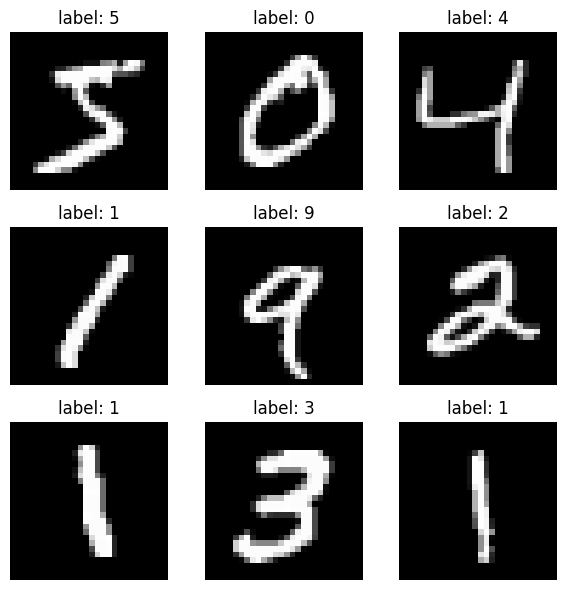

1枚目のラベル: 5
ピクセル値  min: -0.4242129623889923  max: 2.821486711502075


In [17]:
# === 完成済みコード：そのまま実行して出力を観察してください ===
# （問題2で train_dataset を作成してから実行してください）
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for ax, idx in zip(axes.flat, range(9)):
    img, label = train_dataset[idx]
    ax.imshow(img.squeeze(), cmap="gray")  # (1,28,28) -> squeeze -> (28,28)
    ax.set_title(f"label: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# 1枚目のピクセル値の範囲を確認
img0, label0 = train_dataset[0]
print("1枚目のラベル:", label0)
print("ピクセル値  min:", img0.min().item(), " max:", img0.max().item())


In [18]:
# === ✍️ 問題3 解答（採点対象）===

# 観察1（画像とラベルは正しく対応していたか）：
観察1_画像とラベルは正しく対応していたか = """
対応していた（3×3 の画像の数字とタイトルの label が一致。1 件目は 5）。
"""

# 観察2（ピクセル値の min / max は？ 選んだ transform（A / B）でこの範囲はどう変わると考えられるか）：
pixel_min = "-0.4242"
pixel_max = "2.8215"
transform_による違いの考察 = "今回の transform C（Normalize(0.1307, 0.3081)）では min = -0.4242（= (0-0.1307)/0.3081）、max = 2.8215（= (1-0.1307)/0.3081）。A（ToTensor のみ）なら 0.0〜1.0、B（Normalize(0.5,0.5)）なら -1.0〜1.0 になる。Normalize は (x − 平均)/標準偏差で画素値の範囲をずらして拡大するので、選んだ transform によって範囲が変わる。"

## 問題4　DataLoader とミニバッチの理解　【骨格+実験】
***

### バッチのデータ構造

DataLoader が返す1バッチのデータ構造を理解することは，第15回以降の実装に直結する：

```
images: shape (64, 1, 28, 28)
  64 = バッチサイズ
   1 = チャネル数（グレースケール）
  28 = 画像の高さ（ピクセル）
  28 = 画像の幅（ピクセル）

labels: shape (64,)
  64個のラベル（0〜9の整数）
```

### Flatten（平坦化）の必要性

全結合層（Fully Connected Layer, `nn.Linear`）は**1次元ベクトル**を入力として受け取る。`(1, 28, 28)` の3次元テンソルをそのまま入れることはできないので，`(784,)` の1次元ベクトルに変形（flatten）する必要がある：

```
28 × 28 = 784 → これが全結合層への入力次元数
```

`view(-1, 784)` の `-1` は「残りの次元を自動計算する」という意味で，バッチサイズを保ったまま flatten できる：
```
(64, 1, 28, 28) → view(-1, 784) → (64, 784)
```

> **第15回との接続**: 第15回では `SimpleMLP` の `forward` メソッドで `x = x.view(-1, 784)` を最初に書く。これがこの flatten 操作だ。

### 課題

下のコードセルは，指定した `batch_size` で `DataLoader` を作り，**1エポックのイテレーション数（バッチの個数）** と **1バッチの shape**、さらに **flatten 前後の shape** を出力する **完成形**です。（問題2で `train_dataset` を作ってから実行してください）

なお、**flatten する関数 `flatten` の中身1行はあなたが書きます**（`# ★あなたが書く★`。ループの中で各バッチに使われます）。`BATCH_SIZE_EXPERIMENTS` リスト（★印）で **最低5通り**（例：16 / 32 / 64 / 128 / 256）を**1回の実行でループ**します。実行後に表示される `experiment_log_run` の値を，**✍️ 解答用コードセルの `experiment_log`** に転記してください。

> **考察**: `batch_size` を 2倍にすると、1エポックのイテレーション数はどう変わりましたか？ また `images.shape` の最初の数字（バッチサイズ）はどう変わりましたか？ なぜそうなるのか、解答用コードセルに書いてください。
>
> （`flatten 後` の `(N, 784)` の `784 = 28 × 28` は第15回で `nn.Linear` の入力次元になります。）

In [19]:
# （問題2で train_dataset を作成してから実行してください）
import pandas as pd

# === ★ここを変えて実験する★：比較する batch_size の一覧 ===
BATCH_SIZE_EXPERIMENTS = [16, 32, 64, 128, 256]

# ★あなたが書く★：images（形 (N, 1, 28, 28)）を (N, 784) に平坦化して返す（1行）
#   ヒント: Tensor の view を使う。-1 は「残りの次元を自動で計算」の意味
def flatten(images):
    return images.view(-1, 784)


experiment_log_run = []
for batch_size in BATCH_SIZE_EXPERIMENTS:
    exp_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    n_iter = len(exp_loader)
    images, labels = next(iter(exp_loader))
    flat = flatten(images)                 # 上で自分で書いた flatten（第15回の入力次元 784 の確認用）
    row = {
        "batch_size": batch_size,
        "iterations_per_epoch": n_iter,
        "images_shape": str(tuple(images.shape)),
        "flatten_shape": str(tuple(flat.shape)),
    }
    experiment_log_run.append(row)
    print(f"batch_size={batch_size:3d}  iterations={n_iter:4d}  images.shape={images.shape}  flat.shape={flat.shape}")

print("\n--- experiment_log_run（解答欄の experiment_log に転記）---")
print(pd.DataFrame(experiment_log_run))


batch_size= 16  iterations=3750  images.shape=torch.Size([16, 1, 28, 28])  flat.shape=torch.Size([16, 784])
batch_size= 32  iterations=1875  images.shape=torch.Size([32, 1, 28, 28])  flat.shape=torch.Size([32, 784])
batch_size= 64  iterations= 938  images.shape=torch.Size([64, 1, 28, 28])  flat.shape=torch.Size([64, 784])
batch_size=128  iterations= 469  images.shape=torch.Size([128, 1, 28, 28])  flat.shape=torch.Size([128, 784])
batch_size=256  iterations= 235  images.shape=torch.Size([256, 1, 28, 28])  flat.shape=torch.Size([256, 784])

--- experiment_log_run（解答欄の experiment_log に転記）---
   batch_size  iterations_per_epoch      images_shape flatten_shape
0          16                  3750   (16, 1, 28, 28)     (16, 784)
1          32                  1875   (32, 1, 28, 28)     (32, 784)
2          64                   938   (64, 1, 28, 28)     (64, 784)
3         128                   469  (128, 1, 28, 28)    (128, 784)
4         256                   235  (256, 1, 28, 28)    (256, 7

In [20]:
# === ✍️ 問題4 解答（採点対象）===
import pandas as pd


# (4-a) 実験ログ（上のセルで表示した experiment_log_run を転記。5通り以上）
experiment_log = pd.DataFrame([
    {'row': 1, 'batch_size': 16, 'iterations_per_epoch': 3750, 'images_shape': '(16, 1, 28, 28)', 'flatten_shape': '(16, 784)'},
    {'row': 2, 'batch_size': 32, 'iterations_per_epoch': 1875, 'images_shape': '(32, 1, 28, 28)', 'flatten_shape': '(32, 784)'},
    {'row': 3, 'batch_size': 64, 'iterations_per_epoch': 938, 'images_shape': '(64, 1, 28, 28)', 'flatten_shape': '(64, 784)'},
    {'row': 4, 'batch_size': 128, 'iterations_per_epoch': 469, 'images_shape': '(128, 1, 28, 28)', 'flatten_shape': '(128, 784)'},
    {'row': 5, 'batch_size': 256, 'iterations_per_epoch': 235, 'images_shape': '(256, 1, 28, 28)', 'flatten_shape': '(256, 784)'},
])

# (4-b) 考察：batch_size を2倍にするとイテレーション数とバッチサイズはどう変わるか／その理由
answer_4_b = """
batch_size を 2 倍にすると、1 エポックのイテレーション数（バッチの個数）はほぼ半分になり（3750 → 1875 → 938 → 469 → 235）、images.shape の最初の数字（バッチサイズ）は 2 倍になる。イテレーション数 = ceil(60000 / batch_size) で、全データ 60000 枚を 1 バッチ分ずつ取り出すから（938 は 60000/64 = 937.5 の切り上げ）。バッチが大きいほど 1 回の更新が安定するが更新回数が減る（学習率との兼ね合いが必要。#16 の lr=0.5 & batch=16 が不安定だった理由でもある）。
"""

